In [20]:
from langchain.chat_models import init_chat_model
from typing import Annotated,List,Dict,Literal,Optional,Any
import operator
from langchain.agents import  create_agent
from langchain_huggingface import HuggingFaceEndpoint,ChatHuggingFace
from langchain_community.tools import DuckDuckGoSearchResults
from langchain.agents.middleware import ToolCallLimitMiddleware,ModelRetryMiddleware
import re
from langchain.tools import tool
from typing import TypedDict
from langchain_core.prompts import ChatPromptTemplate,PromptTemplate
from langgraph.graph import StateGraph,START,END
from langchain_core.output_parsers import  PydanticOutputParser
from langchain_community.retrievers import  WikipediaRetriever
from langchain.messages import HumanMessage
from typing import Annotated
from deepagents import create_deep_agent
from langchain_mistralai import  ChatMistralAI
from langchain_core.tools.retriever import create_retriever_tool
from pydantic import BaseModel,Field
import os 
from dotenv import load_dotenv
from langgraph_supervisor import create_supervisor

load_dotenv()

True

In [80]:
retriever=WikipediaRetriever()

In [81]:
wikipidea=create_retriever_tool(retriever=retriever,name='wikipedia_retriever',description='Retrieves information from Wikipedia',response_format='content')

In [21]:
duckduckgo=DuckDuckGoSearchResults(top=100,output_format='json',description=' a tool to get nrws from duck duck go')
model=ChatMistralAI()

In [83]:
deep=create_deep_agent(
    model=model,
    tools=[duckduckgo,wikipidea],
    name='deep_agent',
    system_prompt='a retriever which retriever information from the internet using tools USING NAME duckduckgo for online and USING NAME wikipidea for wikipidea INFORMATION SO YOU NEED TO GIVE A DEEP RESEARCH',
    
)

In [84]:
from pydantic import BaseModel, Field

class Router(BaseModel):
    research_needed: bool = Field(
        description="True if the question requires up-to-date or external research"
    )
    response: str = Field(
        description="Short explanation of the decision"
    )

In [85]:
class ResearchEval(BaseModel):
    evaluation:Literal['needs_more_research','this_is_enought']=Field(...,description='you have to do the evalaution of the research given to you and on the basis of that you need to decide weather you need more research or this is enough')
    feedback:str=Field(...,description='you need to give the feedback to the researcher so it can expand and improve its research')

In [86]:
parser2=PydanticOutputParser(pydantic_object=ResearchEval)

In [87]:
parser=PydanticOutputParser(pydantic_object=Router)

In [88]:
class State(TypedDict):
    """State of the agent."""
    topic:str
    plan:str
    research_needed:bool
    researched_output:Annotated[list[str],operator.add]
    final_output:str
    feedback:str
    evaluation:Literal['needs_more_research','this_is_enought']
    iteration:int

In [89]:
async def making_orchestrator_node(state: State) -> dict:
    topic = state.get('topic')
    response = await model.ainvoke(f"Plan for: {topic}")
    return {"plan": response.content, "iteration": 0} # Explicitly start iteration at 0

In [90]:
async def router(state:  State)->str:
    " router which decides that if search is needed or not"
    plan=state.get('plan','')
    if plan is not None:
        prompt=PromptTemplate(
            template=" you are a router and your work is to decide weather there is a need for online search on this \n {plan} and instructions are \n {format_instructions} or not and make sure to think a lot if training data is enough for this topic or not",
            input_variables=['plan'],
            partial_variables={'format_instructions':parser.get_format_instructions()}
        )
        prompt=prompt.invoke({'plan':plan})
        response=await model.ainvoke(input=prompt)
        output=parser.parse(response.content)
        if output.research_needed is True:
            return "search"
        else:
            return 'final'
        
    return 'final'
    

In [91]:
async def  researcher(state:State)->State:
    '''this node makes the final output'''
    plan=state.get('plan','')

    if plan:
        deep=create_deep_agent(
                model=model,
                tools=[duckduckgo,wikipidea],
                name='deep_agent',
                system_prompt='a retriever which retriever information from the internet using tools USING NAME duckduckgo for online and USING NAME wikipidea for wikipidea INFORMATION SO YOU NEED TO GIVE A DEEP RESEARCH',
                
)             
        agent_output=await deep.ainvoke({'messages':[HumanMessage(content=f'using this {plan} make a detailed research and give me the output make sure its thoroughly covers all aspects of the topic')]})

        return {'researched_output':[agent_output['messages'][-1].content],'iteration':state['iteration']+1}
    
    else:

        return {'final_output':'no plan found'}

In [92]:
async def final_writer(state:State)->State:

    researched_output=state.get('research_output','')
    topic=state.get('topic','')
    
    if researched_output is not None:

        final_output=await model.ainvoke(f' using the given research \n {researched_output} \n draft a blog which is professional good structure human like and easy to read on the topic {topic}')

        return {'final_output':final_output}
    
    elif state.get('plan','') is not None:
        
        plan=state.get('plan','')
        final_output=await model.ainvoke(f' using the given plan \n {plan} \n draft a blog which is professional good structure human like and easy to read')
        return {'final_output':final_output}
     
    else:
        return State

In [93]:
a=model.with_structured_output(ResearchEval)

In [94]:
async def evaluate_research(state:State)->State:

    researched_output=state.get('researched_output','')
    plan=state.get('plan','')
    prompt=PromptTemplate(
        template='you need to evaluate the research output: {researched_output} and decide whether more research is needed to make a good blog or not and give a reason for your decision based on this plan: {plan}',
        input_variables=['researched_output','plan'],
        partial_variables={'format_instructions' :parser2.get_format_instructions()}

    )
    prompt=prompt.invoke({'researched_output':researched_output,'plan':plan})

    if researched_output and plan is not None:
        evaluation=await a.ainvoke(prompt)       
        if evaluation.evaluation =='needs_more_research':
            return {'evaluation':evaluation.evaluation,'feedback':evaluation.feedback}
        else:
            return {'evaluation':evaluation.evaluation,'feedback':evaluation.feedback}


In [95]:
def itwf(state:State)->str:
    if state.get('evaluation')=='needs_more_research' and state.get('iteration')<5:
        return 'research'
    else:
        return 'end_research'

In [96]:
graph=StateGraph(state_schema=State)

# Add nodes
graph.add_node("orchestrator", making_orchestrator_node)
graph.add_node("researcher", researcher)
graph.add_node('evaluator',evaluate_research)
graph.add_node('final_writer',final_writer)

# Add edges
graph.add_edge(START, "orchestrator")
graph.add_conditional_edges('orchestrator',router,{'search':'researcher','final':'final_writer'})
graph.add_conditional_edges('evaluator',itwf,{'research':'researcher','end_research':'final_writer'})
graph.add_edge('researcher','evaluator')
graph.add_edge("final_writer", END)

# Compile the graph
app = graph.compile()


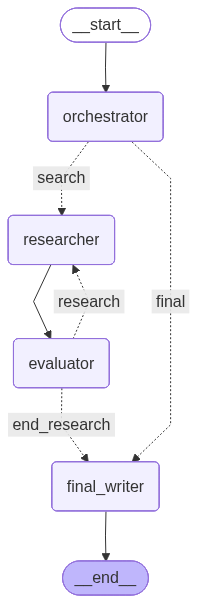

In [97]:
app

In [98]:
output=await app.ainvoke({'topic':'write about OPENCLAW  ','iteration':0})

In [101]:
output

{'topic': 'write about OPENCLAW  ',
 'plan': 'Here’s a structured plan to write about **OpenClaw**, a decentralized trading platform built on the Solana blockchain. This plan ensures a comprehensive and engaging article.\n\n---\n\n### **Title:**\n*"OpenClaw: Decentralized Trading on Solana – A Deep Dive"*\n\n### **Outline:**\n\n#### **1. Introduction**\n   - Brief overview of OpenClaw: A decentralized trading platform on Solana.\n   - Purpose: To provide liquidity, reduce slippage, and offer competitive trading fees.\n   - Key features: Cross-chain swaps, low fees, and decentralized governance.\n\n#### **2. What is OpenClaw?**\n   - Definition: A decentralized exchange (DEX) aggregator and liquidity protocol.\n   - Core functions:\n     - Aggregates liquidity from multiple DEXs for optimal trades.\n     - Enables cross-chain swaps (e.g., Solana ↔ Ethereum).\n     - Uses a unique **Clawback Mechanism** to minimize slippage.\n   - Token: $Claw (utility token for governance, staking, and 

In [102]:
output['final_output']

AIMessage(content="# **OpenClaw: The Future of AI-Powered Automation**\n\n## **Introduction**\n\nIn today’s fast-paced digital landscape, businesses and developers are constantly seeking efficient, scalable, and intelligent automation solutions. Enter **OpenClaw**, an open-source AI-powered automation framework designed to streamline workflows, enhance productivity, and reduce manual intervention.\n\nWhether you're a developer, a business owner, or an automation enthusiast, OpenClaw offers a powerful yet flexible toolkit to automate repetitive tasks, integrate systems, and optimize operations. In this blog, we’ll explore what OpenClaw is, its key features, benefits, and how it stands out in the automation space.\n\n---\n\n## **What is OpenClaw?**\n\nOpenClaw is an **open-source automation framework** that leverages artificial intelligence to automate workflows across different platforms and applications. Unlike traditional automation tools that rely on rigid scripting, OpenClaw uses **

# time travel in langgraph


In [73]:
from langgraph.types import interrupt
from langgraph.graph import StateGraph,START,END
from langgraph.prebuilt import  ToolNode,tools_condition
from langchain_community.tools.ddg_search import DuckDuckGoSearchRun
from langgraph.types import interrupt,Command
from langgraph.checkpoint.memory import InMemorySaver
from langchain_community.tools.google_search import GoogleSearchResults
from typing_extensions import TypedDict,Annotated,List,AnyStr
from operator import add

In [74]:
memory=InMemorySaver()

In [75]:
tool=DuckDuckGoSearchRun(top=100,description=' a tool to get news from duck duck go')

In [76]:
tool.invoke('what is openclaw')

"OpenClaw , formerly Moltbot, has burst into the mainstream. Here's everything you need to know about the viral AI agent now known as OpenClaw . OpenClaw is an open agent platform that runs on your machine and works from the chat apps you already use. WhatsApp, Telegram, Discord, Slack, Teams—wherever you are, your AI assistant follows. Here's everything cool and scary about OpenClaw , the autonomous AI agent that lives on your device, responds to your texts, and is taking the internet by storm. Learn what OpenClaw (aka Moltbot and Clawdbot) is and how this local, open source AI assistant can run scripts, manage files, and automate around the clock. OpenClaw Is the Hot New AI Agent, But Is It Safe to Use? Previously Clawdbot and then Moltbot, this agent can take actions without you having to prompt it and make those decisions by accessing ..."

In [77]:
class chattoolstate(TypedDict):
    input:str
    messages:Annotated[List[str],add]
    output:str

In [111]:
def chat(state:chattoolstate)->chattoolstate:
    output=interrupt('what do you want to  ask?')
    output=model.invoke(input=f' your query is this  {output}')
    if output=='exit':
        return interrupt('exit')
    
    return {'messages':[output]}


In [112]:
tool_node=ToolNode(tools=[tool])

In [113]:
graph=StateGraph(state_schema=chattoolstate)
graph.add_node('chat',chat)
graph.add_node('tools',tool_node)


graph.add_edge(START,'chat')
graph.add_conditional_edges('chat',tools_condition)
graph.add_edge('tools','chat')

In [114]:
graph=graph.compile(checkpointer=memory)

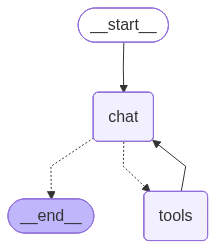

In [115]:
graph

In [116]:
config={'configurable':{'thread_id':'1'}}

In [117]:
output=graph.invoke({'input':' what is the latest news on openclaw and moltbot?'},config=config)

In [118]:
output['__interrupt__'][0].value

'what do you want to  ask?'

In [119]:
human_input=input('enter the human input after research is done')

In [120]:
human_input=graph.invoke(Command(resume={'output':human_input}),config=config)

In [121]:
human_input

{'input': ' what is the latest news on openclaw and moltbot?',
 'messages': [AIMessage(content='It looks like your query is in Hindi and translates to "I don\'t know." Since you\'re referring to tools in a "tool node," I\'ll assume you\'re asking how to use available tools to answer this query or similar ones.\n\nHere’s how you can approach this:\n\n1. **Identify Relevant Tools**: Check the list of tools available in the "tool node" to see which ones might help answer the query. For example:\n   - A translation tool (if the query is in a language you don\'t understand).\n   - A search tool (to find information related to the query).\n   - A knowledge base or database (to retrieve relevant answers).\n\n2. **Use the Tools**:\n   - If the query is unclear or needs translation, use a translation tool to understand it better.\n   - If the query is a question, use a search or knowledge tool to find the answer.\n   - If the query is a statement (like "I don\'t know"), you might need to clarif

In [59]:
output['messages'][-1].content

'I don\'t have direct access to real-time news or databases, but I can help you find the latest information on OpenClaw and MoltBot by guiding you on how to use available tools effectively.\n\nHere are some steps you can take:\n\n1. **Search Engines (e.g., Google, Bing)**:\n   - Use keywords like "OpenClaw latest news" or "MoltBot recent updates" to find articles, blog posts, or official announcements.\n\n2. **GitHub or GitLab Repositories**:\n   - Check the official repositories for OpenClaw and MoltBot (if they are open-source projects). Look for recent commits, issues, or release notes.\n\n3. **Social Media (Twitter, Reddit, LinkedIn)**:\n   - Search for hashtags like #OpenClaw or #MoltBot to see recent discussions or announcements.\n\n4. **Tech News Websites (e.g., TechCrunch, Wired, Ars Technica)**:\n   - Search for articles mentioning OpenClaw or MoltBot.\n\n5. **Official Websites or Blogs**:\n   - Visit the official websites or blogs of OpenClaw and MoltBot (if available) for up